# Inisialisasi Library yang akan digunakan


In [1]:
import cv2
import matplotlib.pylab as plt
import numpy as np
import pandas as pd

Membaca gambar menggunakan fungsi cv2.imread(), yang mengonversi gambar menjadi array numerik. Gambar kemudian ditampilkan menggunakan plt.imshow(), yang memungkinkan gambar ditampilkan di jendela plot. plt.show() digunakan untuk menampilkan gambar pada jendela grafis.

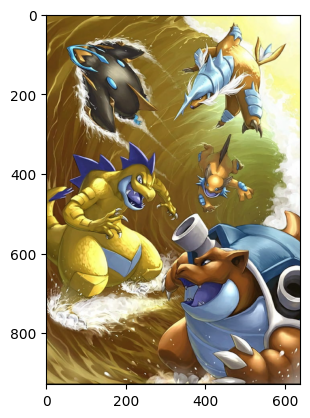

In [2]:
water = cv2.imread('water.jpg')
plt.imshow(water)
plt.show()

Mengubah gambar ke grayscale dengan fungsi cv2.cvtColor() digunakan untuk mengonversi gambar dari format warna BGR (Blue, Green, Red) ke grayscale menggunakan cv2.COLOR_BGR2GRAY. Kemudian, gambar grayscale ditampilkan menggunakan plt.imshow() dengan parameter cmap='gray' untuk memastikan bahwa gambar ditampilkan dalam skala abu-abu. plt.show() digunakan untuk menampilkan gambar setelah konversi.

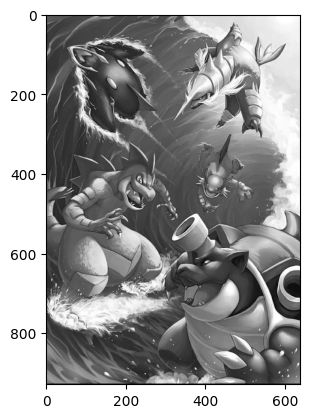

In [3]:
water_grey = cv2.cvtColor(water, cv2.COLOR_BGR2GRAY)
plt.imshow(water_grey, cmap='gray')
plt.show()

# Proses Ekualisasi

Fungsi ekualisasi_histogram(citra) digunakan untuk melakukan ekualisasi histogram pada citra grayscale, yang bertujuan meningkatkan kontras gambar dengan meratakan distribusi intensitas piksel. Fungsi ini pertama-tama menghitung histogram citra, yaitu jumlah kemunculan setiap nilai intensitas piksel dalam rentang 0 hingga 255. Kemudian, fungsi menghitung CDF (Cumulative Distribution Function), yang merupakan akumulasi dari nilai histogram dan menggambarkan distribusi kumulatif intensitas piksel. Setelah itu, CDF dinormalisasi agar nilainya berada dalam rentang 0 hingga 255, dan pemetaan dilakukan untuk mengubah setiap nilai intensitas piksel sesuai dengan nilai yang dihitung dari CDF yang dinormalisasi. Hasilnya adalah citra yang memiliki kontras lebih baik, dengan nilai intensitas yang lebih merata.

In [4]:
def ekualisasi_histogram(citra):
    panjang, lebar = citra.shape

    histogram = np.zeros(256, dtype=int)
    for i in range(panjang):
        for j in range(lebar):
            nilai = citra[i, j]
            histogram[nilai] += 1

    cdf = np.zeros(256, dtype=int)
    for i in range(256):
        cdf[i] = np.sum(histogram[:i+1])

    cdf_min = cdf[cdf > 0].min() if np.any(cdf > 0) else 0
    cdf_norm = np.round((cdf - cdf_min) / (panjang * lebar - cdf_min) * 255).astype(int)

    hasil = np.zeros_like(citra, dtype=int)
    for i in range(panjang):
        for j in range(lebar):
            val = citra[i, j]
            hasil[i, j] = cdf_norm[val]

    return hasil

Melakukan ekualisasi histogram pada citra water_gray dan menampilkan perbandingan antara citra sebelum dan setelah ekualisasi. Pertama, dimensi citra water_gray diambil dengan water_gray.shape untuk mendapatkan panjang dan lebar citra. Selanjutnya, fungsi ekualisasi_histogram(water_gray) dipanggil untuk melakukan ekualisasi histogram pada citra tersebut, menghasilkan citra dengan kontras yang lebih baik yang disimpan dalam variabel hasil. Kemudian, kedua citra (sebelum dan sesudah ekualisasi) ditampilkan berdampingan dalam satu plot menggunakan plt.subplot(). plt.tight_layout() memastikan tampilan gambar teratur, dan plt.show() digunakan untuk menampilkan hasil visualisasi. Citra pertama menunjukkan gambar sebelum ekualisasi, sementara citra kedua menunjukkan gambar setelah ekualisasi.

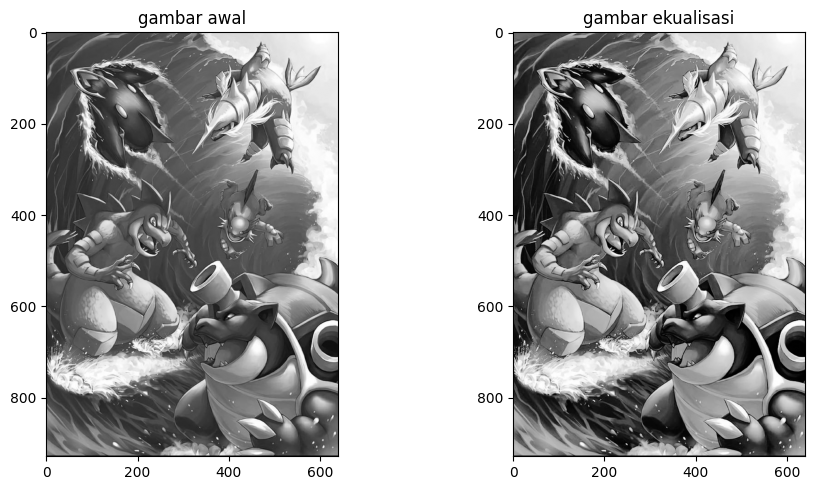

In [5]:
panjang, lebar = water_grey.shape
hasil = ekualisasi_histogram(water_grey)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(water_grey, cmap='gray')
plt.title("gambar awal")

plt.subplot(1, 2, 2)
plt.imshow(hasil, cmap='gray')
plt.title("gambar ekualisasi")

plt.tight_layout()
plt.show()

Fungsi tampilkan_histogram(citra) ini digunakan untuk menampilkan histogram dari citra grayscale. Fungsi pertama-tama menghitung histogram dengan menghitung jumlah kemunculan setiap nilai intensitas piksel (dari 0 hingga 255) dalam citra. Histogram ini disimpan dalam array histogram, yang nantinya digunakan untuk menggambar histogram menggunakan plt.bar(). Fungsi ini menerima parameter warna, yang memungkinkan pengguna untuk memilih warna batang histogram.

In [6]:
def tampilkan_histogram(citra):
    histogram = np.zeros(256, dtype=int)
    for i in range(citra.shape[0]):
        for j in range(citra.shape[1]):
            nilai = citra[i, j]
            histogram[nilai] += 1
    return histogram

Perbandingan Histogram ditampilkan dalam grafik menggunakan fungsi  tampilkan_histogram dan menggunakan plt.subplot(). Histogram diberi judul "Histogram awal" dan "Histogram equalization, label pada sumbu X untuk intensitas piksel, dan label pada sumbu Y untuk jumlah piksel.

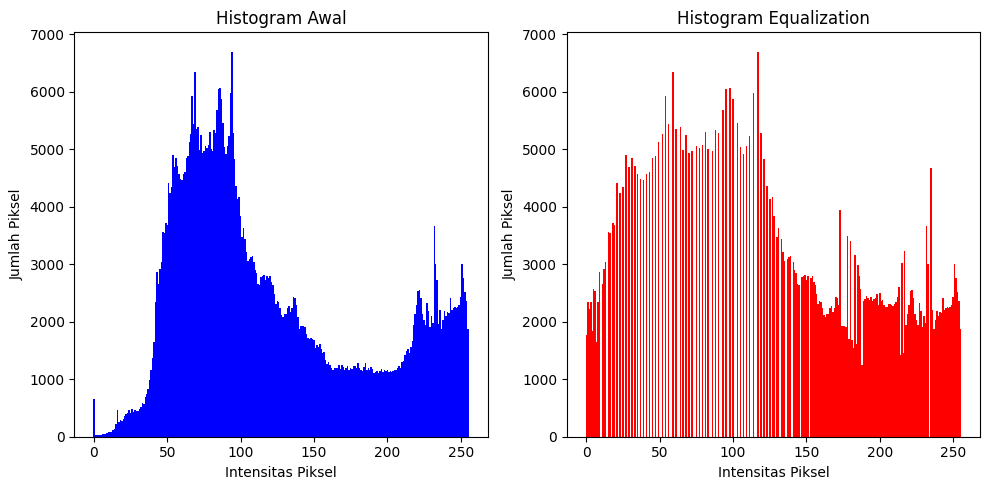

In [7]:
hist_awal = tampilkan_histogram(water_grey)
hist_equalized = tampilkan_histogram(hasil)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.bar(range(256), hist_awal, width=1, color='blue')
plt.title('Histogram Awal')
plt.xlabel('Intensitas Piksel')
plt.ylabel('Jumlah Piksel')

plt.subplot(1, 2, 2)
plt.bar(range(256), hist_equalized, width=1, color='red')
plt.title('Histogram Equalization')
plt.xlabel('Intensitas Piksel')
plt.ylabel('Jumlah Piksel')

plt.tight_layout()
plt.show()

Membaca dua file data eksternal dalam format CSV menggunakan library pandas. Kemudian memvisualisasikannya sebagai grafik batang yang merepresentasikan histogram intensitas warna. Program pertama-tama memuat data dari file target 1.csv dan target 2.csv, lalu menyiapkan sebuah area gambar (figure) yang dibagi menjadi dua bagian secara berdampingan menggunakan fungsi plt.subplot. Pada setiap bagian, fungsi plt.bar digunakan untuk memplot kolom pertama sebagai nilai sumbu X (rentang intensitas 0-255) dan kolom kedua sebagai nilai sumbu Y (frekuensi atau jumlah pixel), dengan memberikan warna hijau untuk target pertama dan merah untuk target kedua agar sesuai dengan format visualisasi pengolahan citra.

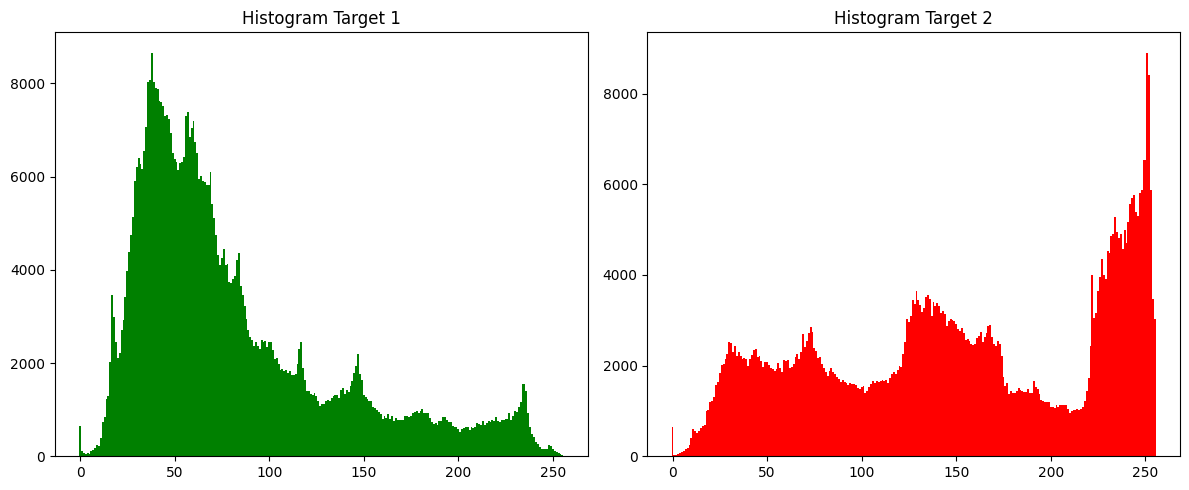

In [14]:
target1 = pd.read_csv('target 1.csv')
target2 = pd.read_csv('target 2.csv')

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.bar(target1.iloc[:, 0], target1.iloc[:, 1], color='green', width=1.0)
plt.title('Histogram Target 1')

plt.subplot(1, 2, 2)
plt.bar(target2.iloc[:, 0], target2.iloc[:, 1], color='red', width=1.0)
plt.title('Histogram Target 2')

plt.tight_layout()
plt.show()

# Proses Spesifikasi

Fungsi spesifikasi_histogram(citra_sumber, citra_target) ini digunakan untuk melakukan histogram matching atau spesifikasi histogram, yaitu proses di mana histogram dari citra sumber diubah agar menyerupai histogram dari citra target. Proses ini bekerja dengan menghitung histogram citra sumber secara manual menggunakan nested loop, mengambil histogram target langsung dari kolom frekuensi pada file CSV, lalu menghitung Cumulative Distribution Function (CDF) untuk keduanya dalam tipe data float guna menjaga akurasi desimal. Setelah nilai CDF normal diperoleh, fungsi membangun tabel pemetaan (lookup table) dengan mencari selisih terkecil antara nilai kumulatif sumber dan target menggunakan np.argmin, kemudian menerapkan hasil pemetaan tersebut ke setiap piksel citra asli untuk menghasilkan citra baru dengan karakteristik visual yang sesuai dengan spesifikasi yang diinginkan.

In [ ]:
def spesifikasi_histogram(citra_sumber, df_target):

    panjang_sumber, lebar_sumber = citra_sumber.shape

    histogram_sumber = np.zeros(256, dtype=int)
    for i in range(panjang_sumber):
        for j in range(lebar_sumber):
            nilai = citra_sumber[i, j]
            histogram_sumber[nilai] += 1

    histogram_target = df_target.iloc[:, 1].values.astype(float)

    cdf_sumber = np.zeros(256, dtype=float)
    kumulatif_sumber = 0
    total_pixel_sumber = panjang_sumber * lebar_sumber
    for i in range(256):
        kumulatif_sumber += histogram_sumber[i]
        cdf_sumber[i] = kumulatif_sumber / total_pixel_sumber

    cdf_target = np.zeros(256, dtype=float)
    kumulatif_target = 0
    total_pixel_target = np.sum(histogram_target)
    for i in range(256):
        kumulatif_target += histogram_target[i]
        cdf_target[i] = kumulatif_target / total_pixel_target

    pemetaan = np.zeros(256, dtype=int)
    for i in range(256):
        idx = np.argmin(np.abs(cdf_target - cdf_sumber[i]))
        pemetaan[i] = idx

    hasil = np.zeros_like(citra_sumber)
    for i in range(panjang_sumber):
        for j in range(lebar_sumber):
            nilai = citra_sumber[i, j]
            hasil[i, j] = pemetaan[nilai]

    return hasil


Melakukan spesifikasi histogram pada citra hasil dengan menggunakan target1 dan target2 sebagai target. Fungsi spesifikasi_histogram() diterapkan untuk menghasilkan dua citra baru, yaitu spek1 dan spek2, yang masing-masing mencocokkan histogram hasil dengan histogram dari target1 dan target2.

Setelah itu, kedua citra hasil spesifikasi histogram (spek1 dan spek2) ditampilkan berdampingan dalam satu gambar menggunakan plt.subplot(). Citra pertama, spek1, menunjukkan hasil spesifikasi histogram dengan citra target target1, dan citra kedua, spek2, menunjukkan hasil spesifikasi histogram dengan citra target target2. Setiap citra diberi judul dengan plt.title() dan sumbu ditampilkan dengan plt.axis('on').

(np.float64(-0.5), np.float64(638.5), np.float64(928.5), np.float64(-0.5))

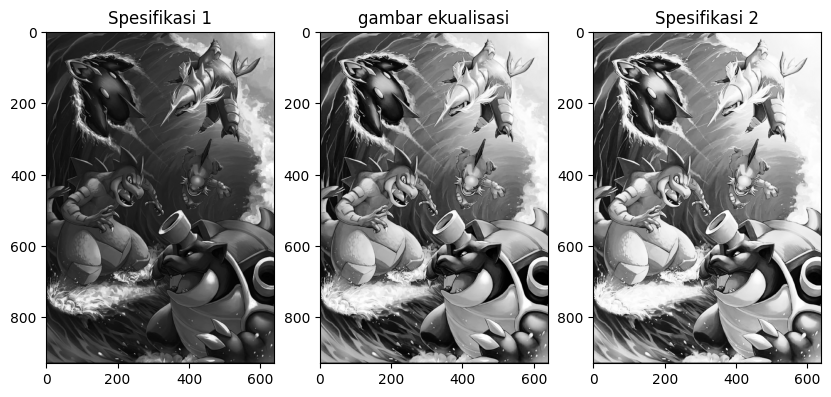

In [47]:
spek1 = spesifikasi_histogram(hasil, target1)
spek2 = spesifikasi_histogram(hasil, target2)

plt.figure(figsize=(10, 10))

plt.subplot(1, 3, 1)
plt.imshow(spek1, cmap='gray')
plt.title("Spesifikasi 1")
plt.axis('on')

plt.subplot(1, 3, 2)
plt.title("gambar ekualisasi")
plt.imshow(hasil, cmap='gray')
plt.axis('on')

plt.subplot(1, 3, 3)
plt.title("Spesifikasi 2")
plt.imshow(spek2, cmap='gray')
plt.axis('on')

Fungsi tampilkan_histogram_spek ini berfungsi untuk menampilkan perbandingan distribusi intensitas piksel antara citra hasil spesifikasi dan citra hasil ekualisasi dalam bentuk grafik batang yang telah dinormalisasi. Di dalam fungsi, histogram dihitung menggunakan np.histogram dengan 256 bin, lalu nilainya dibagi dengan total seluruh piksel agar sumbu Y menunjukkan nilai probabilitas desimal, bukan jumlah piksel absolut. Selanjutnya, fungsi plt.bar digunakan dengan lebar bar satu satuan (width=1.0) untuk menciptakan tampilan histogram yang rapat dan kontinu, sementara penggunaan plt.subplot memungkinkan ketiga grafik ditampilkan secara berdampingan dalam satu area gambar dengan skema warna yang berbeda.

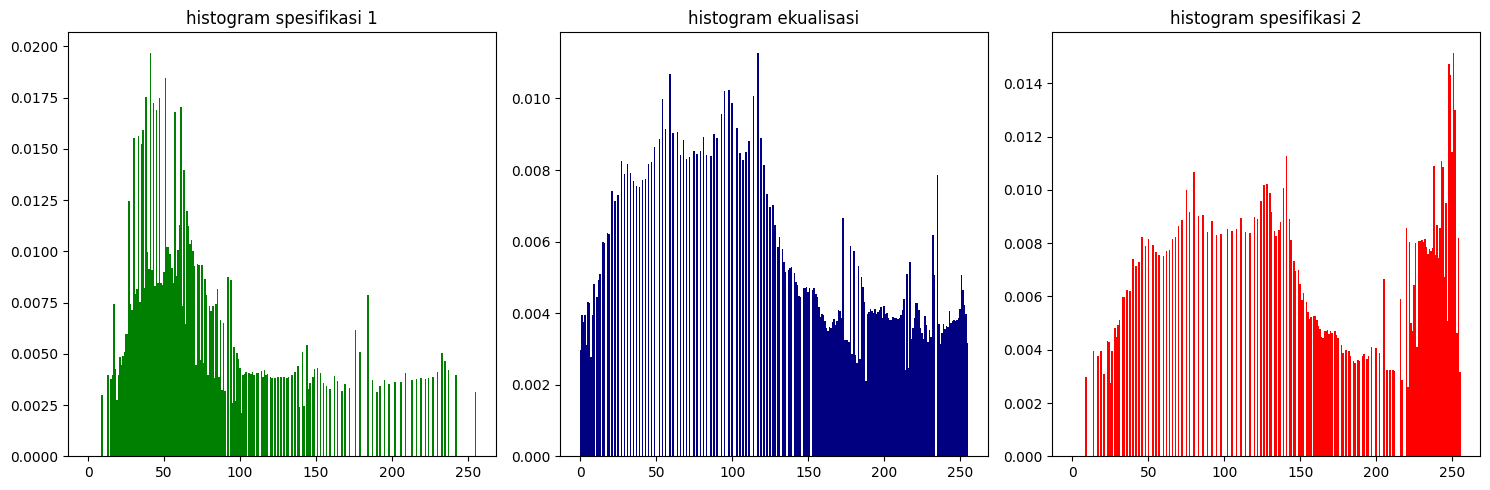

In [49]:
def tampilkan_histogram_spek(citra, judul, warna):
    hist, bins = np.histogram(citra.flatten(), bins=256, range=[0,256])
    hist_norm = hist / hist.sum()
    plt.bar(range(256), hist_norm, color=warna, width=1.0)
    plt.title(judul)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
tampilkan_histogram_spek(spek1, "histogram spesifikasi 1", "green")

plt.subplot(1, 3, 2)
tampilkan_histogram_spek(hasil, "histogram ekualisasi", "navy")

plt.subplot(1, 3, 3)
tampilkan_histogram_spek(spek2, "histogram spesifikasi 2", "red")

plt.tight_layout()
plt.show()

Melakukan proses histogram matching silang antara dua citra hasil spesifikasi sebelumnya dan menampilkan hasilnya dalam tata letak grid 2x2. Proses diawali dengan memanggil fungsi spesifikasi_histogram untuk mengubah distribusi warna citra spek1 agar mengikuti profil target2 serta citra spek2 agar mengikuti profil target1. Selanjutnya, perintah plt.subplot(2, 2, n) digunakan untuk menyusun empat gambar secara sistematis, di mana baris pertama menampilkan citra asli spesifikasi 1 berdampingan dengan hasil transformasinya spesifikasi 1-2, sementara baris kedua menampilkan citra spesifikasi 2 bersama hasil transformasinya spesifikasi 2-1.

(np.float64(-0.5), np.float64(638.5), np.float64(928.5), np.float64(-0.5))

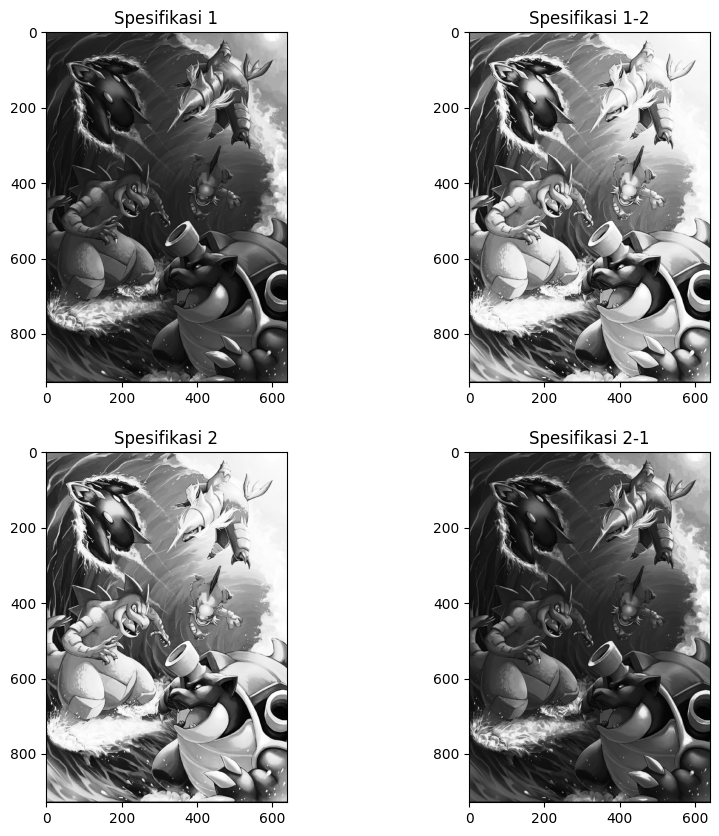

In [72]:
spek1_2 = spesifikasi_histogram(spek1, target2)
spek2_1 = spesifikasi_histogram(spek2, target1)

plt.figure(figsize=(10, 10))

plt.subplot(2, 2, 1)
plt.imshow(spek1, cmap='gray')
plt.title("Spesifikasi 1")
plt.axis('on')

plt.subplot(2, 2, 2)
plt.title("Spesifikasi 1-2")
plt.imshow(spek1_2, cmap='gray')
plt.axis('on')

plt.subplot(2, 2, 3)
plt.title("Spesifikasi 2")
plt.imshow(spek2, cmap='gray')
plt.axis('on')

plt.subplot(2, 2, 4)
plt.title("Spesifikasi 2-1") 
plt.imshow(spek2_1, cmap='gray')
plt.axis('on')

Menampilkan empat histogram citra secara sekaligus dalam satu gambar dengan tata letak grid 2x2. Melalui penggunaan fungsi plt.subplot, setiap posisi dalam grid diisi dengan histogram dari citra yang berbeda menggunakan fungsi bantuan tampilkan_histogram_spek yang telah didefinisikan sebelumnya.Kemudian mwnggunakan plt.tight_layout() di akhir untuk memastikan tidak ada teks atau label yang saling tumpang tindih antar grafik.

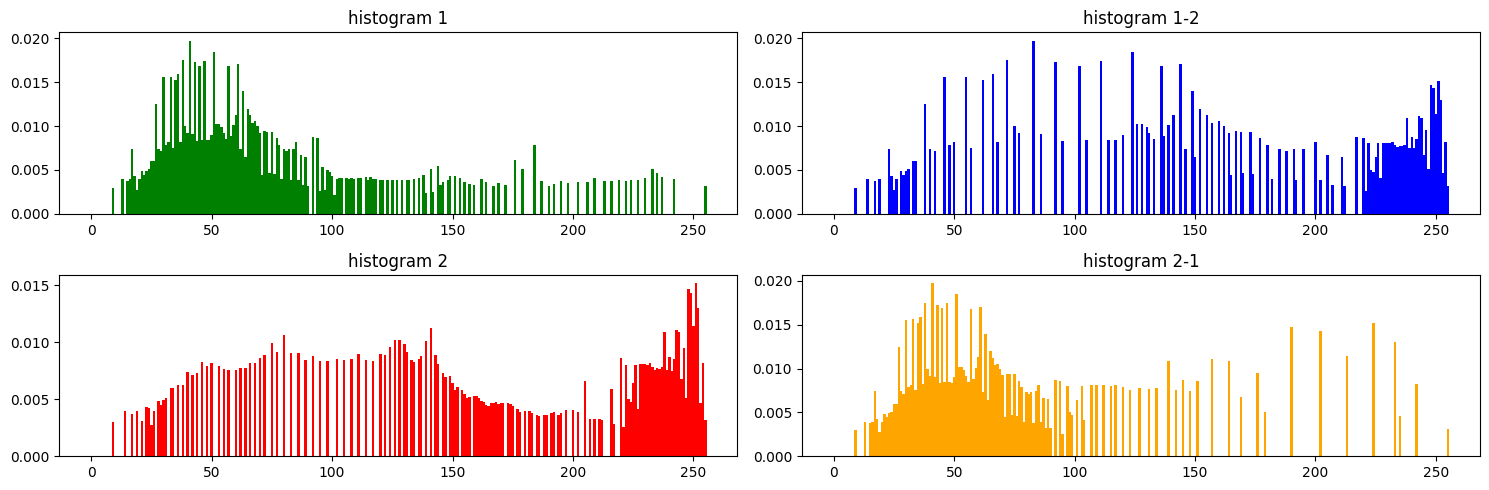

In [73]:
plt.figure(figsize=(15, 5))

plt.subplot(2, 2, 1)
tampilkan_histogram_spek(spek1, "histogram 1", "green")

plt.subplot(2, 2, 2)
tampilkan_histogram_spek(spek1_2, "histogram 1-2", "blue")

plt.subplot(2, 2, 3)
tampilkan_histogram_spek(spek2, "histogram 2", "red")

plt.subplot(2, 2, 4)
tampilkan_histogram_spek(spek2_1, "histogram 2-1", "orange")

plt.tight_layout()
plt.show()